# LightGBM, XGBoost и CatBoost: сравнение GBDT-библиотек


## 1. Что такое GBDT

**GBDT** — Gradient Boosted Decision Trees, то есть градиентный бустинг над решающими деревьями.

Модель строит ансамбль деревьев последовательно: каждое следующее дерево пытается исправить ошибки предыдущих. Такой подход часто очень хорошо работает с табличными данными.

LightGBM
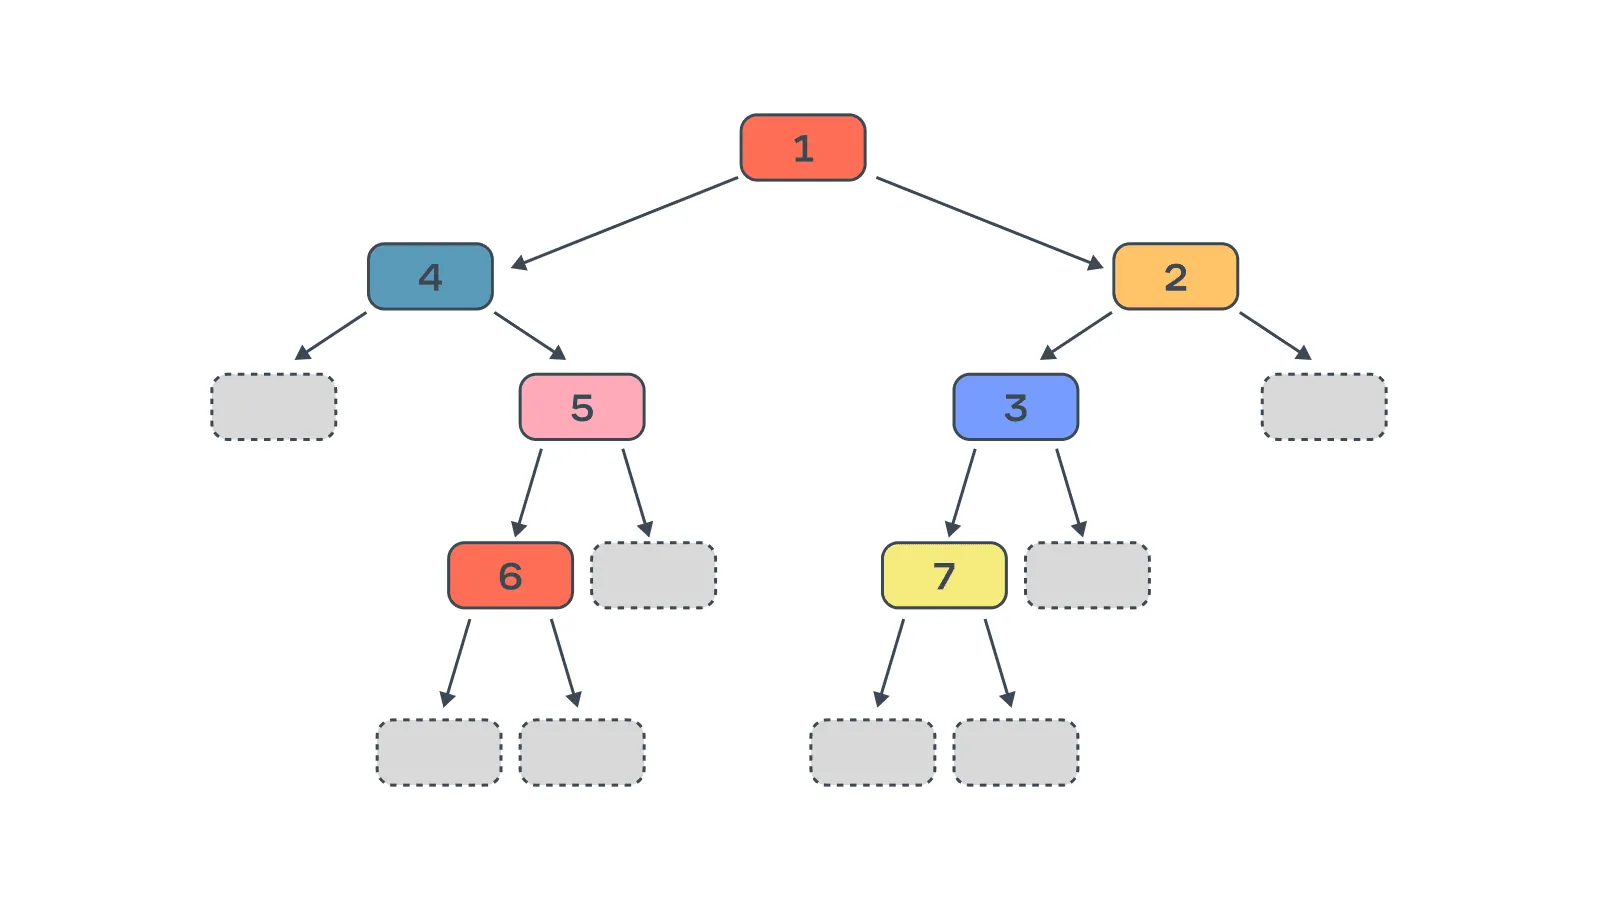

XGBoost

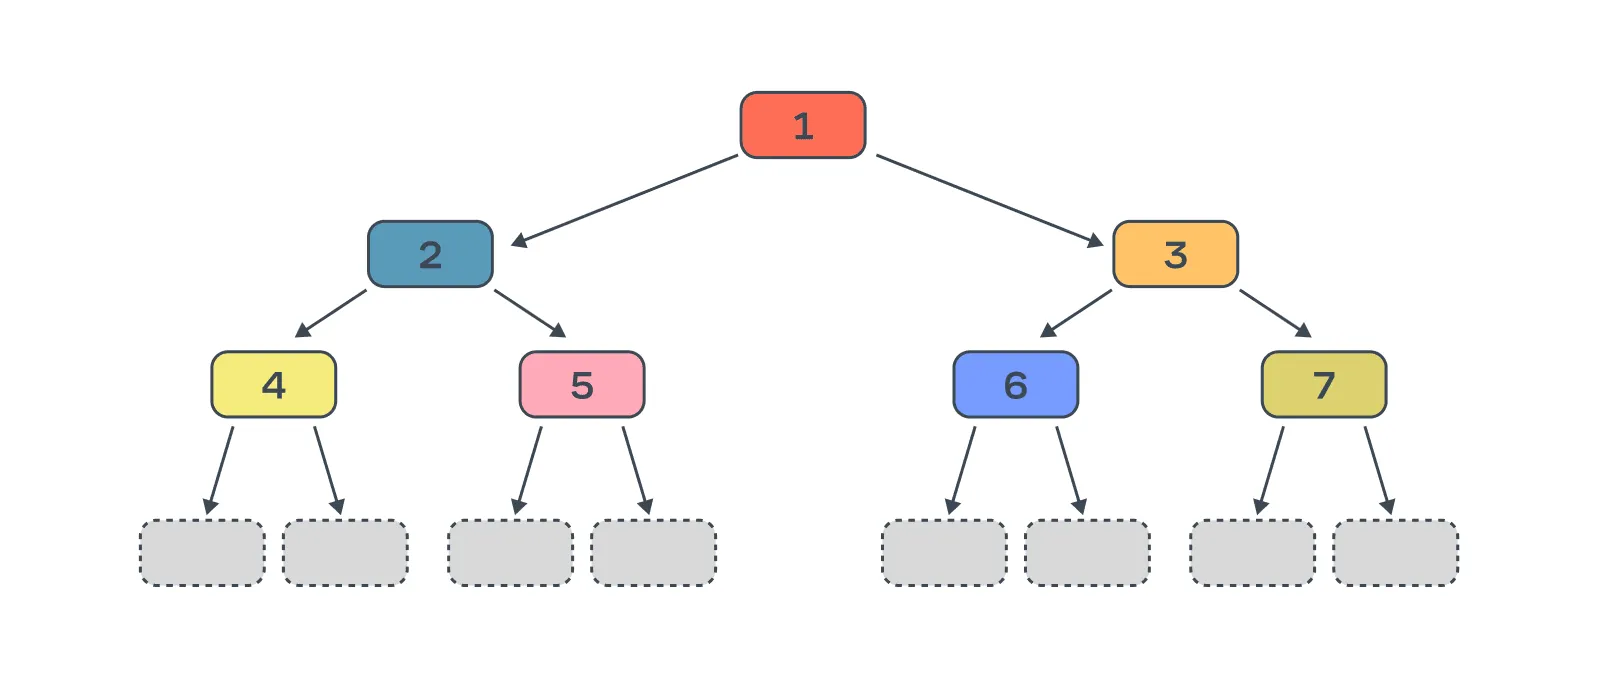

CatBoost

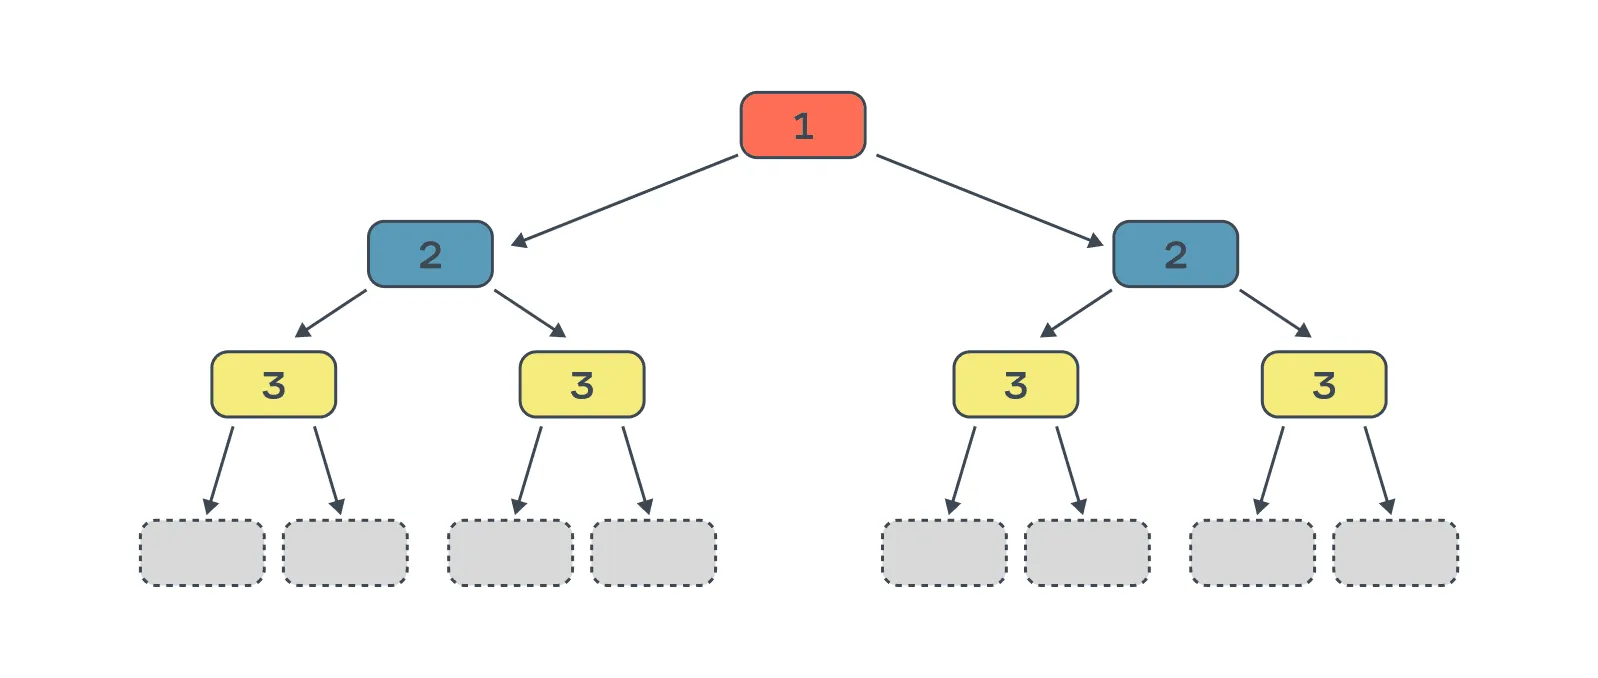

## 2. Основные различия

| Библиотека | Главная идея | Когда использовать |
|---|---|---|
| **XGBoost** | Надёжная и зрелая реализация GBDT | Универсальный baseline для табличных задач |
| **LightGBM** | Быстрое обучение, особенно на больших таблицах | Много строк, много признаков, быстрые эксперименты |
| **CatBoost** | Сильная работа с категориальными признаками | Много категорий: районы, типы объектов, классы дорог |

Общее правило:

- **XGBoost** — хороший универсальный старт;
- **LightGBM** — когда важна скорость;
- **CatBoost** — когда много категориальных признаков.

## 3. Плюсы и минусы

### LightGBM

**Плюсы:**
- быстрый на больших данных;
- есть scikit-learn API;
- хорошо работает с большим количеством признаков.

**Минусы:**
- может переобучаться на маленьких выборках;
- требует аккуратной настройки `num_leaves`, `max_depth`, `min_child_samples`.

### XGBoost

**Плюсы:**
- стабильный и популярный инструмент;
- хорошая документация;
- подходит для регрессии, классификации и ранжирования.

**Минусы:**
- на очень больших данных может быть медленнее LightGBM;
- категориальные признаки часто требуют дополнительной обработки.

### CatBoost

**Плюсы:**
- умеет работать с категориальными признаками напрямую;
- часто даёт сильный результат “из коробки”;
- меньше ручной предобработки категорий.

**Минусы:**
- иногда обучается дольше;
- важно правильно указать категориальные признаки;
- модель может быть тяжелее для использования в продакшене.

## 4. Установка

In [ ]:
!pip install lightgbm xgboost catboost scikit-learn pandas numpy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.6 MB/s eta 0:00:00


## 5. Импорты

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing, make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.preprocessing import OrdinalEncoder

## 6. Пример регрессии

Используем датасет California Housing из scikit-learn.

Задача: предсказать медианную стоимость жилья по признакам района.

In [ ]:
data = fetch_california_housing(as_frame=True)

X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)

X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [ ]:
def evaluate_regression(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)

    return {
        "model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

### 6.1 LightGBM Regressor

In [ ]:
from lightgbm import LGBMRegressor

lgbm_model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42
)

lgbm_model.fit(X_train, y_train)

lgbm_pred = lgbm_model.predict(X_test)
lgbm_result = evaluate_regression("LightGBM", y_test, lgbm_pred)

lgbm_result

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001579 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1838
[LightGBM] [Info] Number of data points in the train set: 15480, number of used features: 8
[LightGBM] [Info] Start training from score 2.070349


{'model': 'LightGBM',
 'MAE': 0.3003443751526516,
 'RMSE': 0.45236578820520684,
 'R2': 0.8453506601982638}

### 6.2 XGBoost Regressor

In [ ]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)
xgb_result = evaluate_regression("XGBoost", y_test, xgb_pred)

xgb_result

{'model': 'XGBoost',
 'MAE': 0.30139542231970795,
 'RMSE': 0.45753742270006686,
 'R2': 0.8417944159063897}

### 6.3 CatBoost Regressor

In [ ]:
from catboost import CatBoostRegressor

cat_model = CatBoostRegressor(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    loss_function="RMSE",
    random_seed=42,
    verbose=0
)

cat_model.fit(X_train, y_train)

cat_pred = cat_model.predict(X_test)
cat_result = evaluate_regression("CatBoost", y_test, cat_pred)

cat_result

{'model': 'CatBoost',
 'MAE': 0.33349452812282937,
 'RMSE': 0.49092093590764696,
 'R2': 0.8178657286976402}

### 6.4 Сравнение регрессии

In [ ]:
regression_results = pd.DataFrame([lgbm_result, xgb_result, cat_result])
regression_results.sort_values("RMSE")

,model,MAE,RMSE,R2
0,LightGBM,0.300344,0.452366,0.845351
1,XGBoost,0.301395,0.457537,0.841794
2,CatBoost,0.333495,0.490921,0.817866


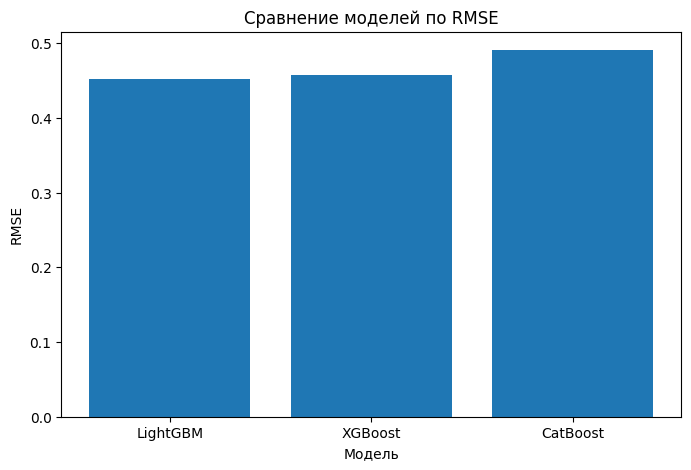

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(regression_results["model"], regression_results["RMSE"])
plt.title("Сравнение моделей по RMSE")
plt.ylabel("RMSE")
plt.xlabel("Модель")
plt.show()

## 7. Важность признаков

In [ ]:
importance_df = pd.DataFrame({
    "feature": X.columns,
    "LightGBM_importance": lgbm_model.feature_importances_,
    "XGBoost_importance": xgb_model.feature_importances_,
    "CatBoost_importance": cat_model.get_feature_importance()
})

importance_df

,feature,LightGBM_importance,XGBoost_importance,CatBoost_importance
0,MedInc,1181,0.427084,36.402372
1,HouseAge,784,0.059987,4.807512
2,AveRooms,830,0.094874,2.576644
3,AveBedrms,644,0.038595,1.137233
4,Population,758,0.022007,1.012997
5,AveOccup,1216,0.143620,14.480722
6,Latitude,1784,0.109025,20.625885
7,Longitude,1803,0.104810,18.956634


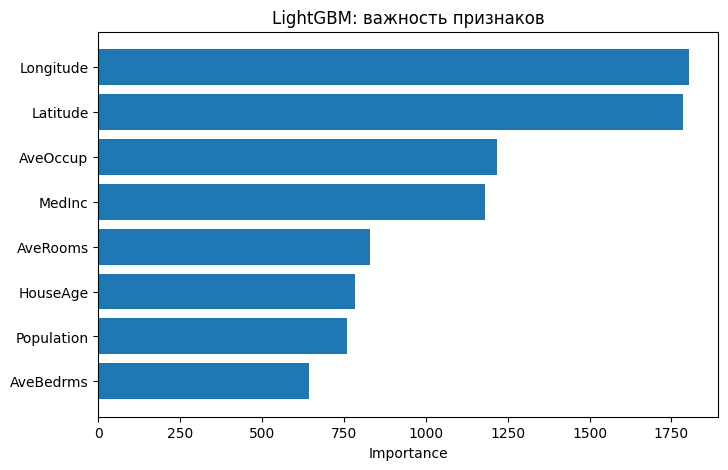

In [ ]:
plot_df = importance_df.sort_values("LightGBM_importance", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(plot_df["feature"], plot_df["LightGBM_importance"])
plt.title("LightGBM: важность признаков")
plt.xlabel("Importance")
plt.show()

## 8. Пример классификации

Создадим синтетический датасет для бинарной классификации.

In [ ]:
X_cls, y_cls = make_classification(
    n_samples=5000,
    n_features=12,
    n_informative=8,
    n_redundant=2,
    random_state=42
)

X_cls = pd.DataFrame(X_cls, columns=[f"feature_{i}" for i in range(12)])

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls,
    y_cls,
    test_size=0.25,
    random_state=42,
    stratify=y_cls
)

In [ ]:
def evaluate_classification(model_name, y_true, y_pred, y_proba):
    return {
        "model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "ROC_AUC": roc_auc_score(y_true, y_proba)
    }

### 8.1 LightGBM Classifier

In [ ]:
from lightgbm import LGBMClassifier

lgbm_clf = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42
)

lgbm_clf.fit(X_train_cls, y_train_cls)

lgbm_cls_pred = lgbm_clf.predict(X_test_cls)
lgbm_cls_proba = lgbm_clf.predict_proba(X_test_cls)[:, 1]

lgbm_cls_result = evaluate_classification(
    "LightGBM",
    y_test_cls,
    lgbm_cls_pred,
    lgbm_cls_proba
)

lgbm_cls_result

[LightGBM] [Info] Number of positive: 1874, number of negative: 1876
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000567 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3060
[LightGBM] [Info] Number of data points in the train set: 3750, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499733 -> initscore=-0.001067
[LightGBM] [Info] Start training from score -0.001067


{'model': 'LightGBM',
 'Accuracy': 0.948,
 'ROC_AUC': np.float64(0.9811865118374703)}

### 8.2 XGBoost Classifier

In [ ]:
from xgboost import XGBClassifier

xgb_clf = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_clf.fit(X_train_cls, y_train_cls)

xgb_cls_pred = xgb_clf.predict(X_test_cls)
xgb_cls_proba = xgb_clf.predict_proba(X_test_cls)[:, 1]

xgb_cls_result = evaluate_classification(
    "XGBoost",
    y_test_cls,
    xgb_cls_pred,
    xgb_cls_proba
)

xgb_cls_result

{'model': 'XGBoost',
 'Accuracy': 0.948,
 'ROC_AUC': np.float64(0.9819954739084132)}

### 8.3 CatBoost Classifier

In [ ]:
from catboost import CatBoostClassifier

cat_clf = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    random_seed=42,
    verbose=0
)

cat_clf.fit(X_train_cls, y_train_cls)

cat_cls_pred = cat_clf.predict(X_test_cls)
cat_cls_proba = cat_clf.predict_proba(X_test_cls)[:, 1]

cat_cls_result = evaluate_classification(
    "CatBoost",
    y_test_cls,
    cat_cls_pred,
    cat_cls_proba
)

cat_cls_result

{'model': 'CatBoost',
 'Accuracy': 0.9552,
 'ROC_AUC': np.float64(0.9813503522569017)}

### 8.4 Сравнение классификации

In [ ]:
classification_results = pd.DataFrame([
    lgbm_cls_result,
    xgb_cls_result,
    cat_cls_result
])

classification_results.sort_values("ROC_AUC", ascending=False)

,model,Accuracy,ROC_AUC
1,XGBoost,0.9480,0.981995
2,CatBoost,0.9552,0.981350
0,LightGBM,0.9480,0.981187


## 9. Категориальные признаки: ключевое различие CatBoost

Создадим простой датасет с категориальными признаками.

Пример похож на городские данные:

- `district` — район;
- `road_type` — тип дороги;
- `has_metro_nearby` — есть ли метро рядом;
- `distance_to_center_km` — расстояние до центра;
- `poi_density` — плотность объектов интереса;
- `road_length_m` — длина дорожного сегмента.

In [ ]:
rng = np.random.default_rng(42)

n = 3000

df_cat = pd.DataFrame({
    "district": rng.choice(["center", "north", "south", "east", "west"], size=n),
    "road_type": rng.choice(["primary", "secondary", "residential", "service"], size=n),
    "has_metro_nearby": rng.choice(["yes", "no"], size=n),
    "distance_to_center_km": rng.uniform(0, 25, size=n),
    "poi_density": rng.uniform(0, 100, size=n),
    "road_length_m": rng.uniform(50, 1000, size=n)
})

df_cat["mobility_score"] = (
    70
    - 1.2 * df_cat["distance_to_center_km"]
    + 0.25 * df_cat["poi_density"]
    + np.where(df_cat["road_type"].isin(["primary", "secondary"]), 15, 0)
    + np.where(df_cat["has_metro_nearby"] == "yes", 10, 0)
    + rng.normal(0, 5, size=n)
)

df_cat.head()

In [ ]:
X_cat = df_cat.drop(columns="mobility_score")
y_cat = df_cat["mobility_score"]

X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(
    X_cat,
    y_cat,
    test_size=0.25,
    random_state=42
)

categorical_features = ["district", "road_type", "has_metro_nearby"]

### 9.1 CatBoost: категории напрямую

CatBoost может принимать список категориальных колонок через `cat_features`.

In [ ]:
cat_model_with_categories = CatBoostRegressor(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    loss_function="RMSE",
    random_seed=42,
    verbose=0
)

cat_model_with_categories.fit(
    X_train_cat,
    y_train_cat,
    cat_features=categorical_features
)

cat_cat_pred = cat_model_with_categories.predict(X_test_cat)

evaluate_regression("CatBoost with categorical features", y_test_cat, cat_cat_pred)

### 9.2 LightGBM и XGBoost: кодирование категорий

Для простоты используем `OrdinalEncoder`.

В реальном проекте можно сравнить:
- OneHotEncoder;
- target encoding;
- нативную обработку категорий;
- CatBoost.

In [ ]:
encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)

X_train_encoded = X_train_cat.copy()
X_test_encoded = X_test_cat.copy()

X_train_encoded[categorical_features] = encoder.fit_transform(
    X_train_cat[categorical_features]
)

X_test_encoded[categorical_features] = encoder.transform(
    X_test_cat[categorical_features]
)

X_train_encoded.head()

In [ ]:
lgbm_cat_model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42
)

lgbm_cat_model.fit(X_train_encoded, y_train_cat)

lgbm_cat_pred = lgbm_cat_model.predict(X_test_encoded)

evaluate_regression("LightGBM with encoded categories", y_test_cat, lgbm_cat_pred)

In [ ]:
xgb_cat_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_cat_model.fit(X_train_encoded, y_train_cat)

xgb_cat_pred = xgb_cat_model.predict(X_test_encoded)

evaluate_regression("XGBoost with encoded categories", y_test_cat, xgb_cat_pred)

## 10. Мини-шпаргалка по параметрам

| Смысл | LightGBM | XGBoost | CatBoost |
|---|---|---|---|
| Число деревьев | `n_estimators` | `n_estimators` | `iterations` |
| Скорость обучения | `learning_rate` | `learning_rate` | `learning_rate` |
| Глубина дерева | `max_depth` | `max_depth` | `depth` |
| Регуляризация | `reg_alpha`, `reg_lambda` | `reg_alpha`, `reg_lambda` | `l2_leaf_reg` |
| Случайность | `subsample`, `colsample_bytree` | `subsample`, `colsample_bytree` | `random_strength`, `bagging_temperature` |

## 11. Практические рекомендации

### Используйте LightGBM, если

- данных много;
- нужна скорость;
- признаки в основном числовые;
- вы хотите быстро делать много экспериментов.

### Используйте XGBoost, если

- нужен надёжный baseline;
- важна стабильность;
- команда уже знает XGBoost;
- нужно много контроля над параметрами.

### Используйте CatBoost, если

- много категориальных признаков;
- хочется меньше ручной предобработки;
- данные содержат районы, типы объектов, категории, классы, названия.